In [ ]:
%pip install -q "ultralytics>=8.4.0" roboflow supervision roboflow sahi pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 595.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.8 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from roboflow import Roboflow
import os

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Directorio de trabajo en tu Drive
drive_path = "/content/drive/MyDrive/Cacao_Project/datasets"
os.makedirs(drive_path, exist_ok=True)
os.chdir(drive_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Bloque 2: Descarga del Dataset (Ajuste a formato YOLO)

Análisis de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from pathlib import Path
from PIL import Image
import concurrent.futures
from tqdm.notebook import tqdm

# 1. Configuración
n_grupos = 6
# Use drive_path directly since the dataset is already downloaded
dataset_path = Path(drive_path)
print(f"Explorando el dataset en: {dataset_path}")

# 2. Recopilar TODAS las imágenes y TODOS los txt en el directorio de forma global
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPG', '.PNG'}
image_files = {}
txt_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = Path(file).suffix.lower()
        if ext in image_extensions:
            image_files[Path(file).stem] = os.path.join(root, file)
        elif ext == '.txt':
            if file.lower() not in ['classes.txt', 'readme.txt', 'data.txt']:
                txt_files.append(os.path.join(root, file))

print(f"-> Archivos de etiquetas (.txt) encontrados: {len(txt_files)}")
print(f"-> Archivos de imágenes encontradas: {len(image_files)}")

# 3. Función optimizada para procesar un solo archivo
def procesar_etiqueta(txt_path):
    bboxes = []
    stem = Path(txt_path).stem

    if stem in image_files:
        img_path = image_files[stem]

        # SUPER OPTIMIZACIÓN: Solo leer el encabezado de la imagen para sacar dimensiones
        try:
            with Image.open(img_path) as img:
                img_w, img_h = img.size
        except Exception:
            return bboxes # Ignorar si la imagen está corrupta

        # Deduciendo el conjunto
        split = 'unknown'
        path_lower = txt_path.lower()
        if 'train' in path_lower: split = 'train'
        elif 'valid' in path_lower: split = 'valid'
        elif 'test' in path_lower: split = 'test'

        # Leer coordenadas YOLO
        try:
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        norm_w = float(parts[3])
                        norm_h = float(parts[4])

                        abs_w = norm_w * img_w
                        abs_h = norm_h * img_h

                        bboxes.append({
                            'split': split,
                            'res_imagen_w': img_w,
                            'res_imagen_h': img_h,
                            'bbox_w': abs_w,
                            'bbox_h': abs_h,
                            'bbox_area': abs_w * abs_h
                        })
        except Exception:
            pass

    return bboxes

Explorando el dataset en: /content/drive/MyDrive/Cacao_Project/datasets
-> Archivos de etiquetas (.txt) encontrados: 9801
-> Archivos de imágenes encontradas: 9799


### Exploración de clases

Extrayendo clases y calculando clústeres...


  0%|          | 0/9801 [00:00<?, ?it/s]


¡Se extrajeron 47523 bounding boxes válidos en total!

--- Agrupación en 6 clústeres ---


,Tamano_CIDIS,cantidad_bboxes,bbox_ancho_prom,bbox_alto_prom,res_img_ancho_prom,res_img_alto_prom
0,0,26793,28.87,42.46,1376.89,1403.77
1,1,12662,64.11,97.06,1321.59,1420.30
2,2,3491,127.89,202.05,1727.27,2134.99
3,3,1976,213.48,368.52,1711.79,2170.37
4,4,1541,309.66,574.64,1189.47,1331.46
5,5,1060,391.58,780.87,1087.93,1154.32


nombre_clase,Enfermo,Sano,Total
Tamano_CIDIS,,,
0,22396,4397,26793
1,9959,2703,12662
2,1951,1540,3491
3,713,1263,1976
4,128,1413,1541
5,18,1042,1060
Total,35165,12358,47523


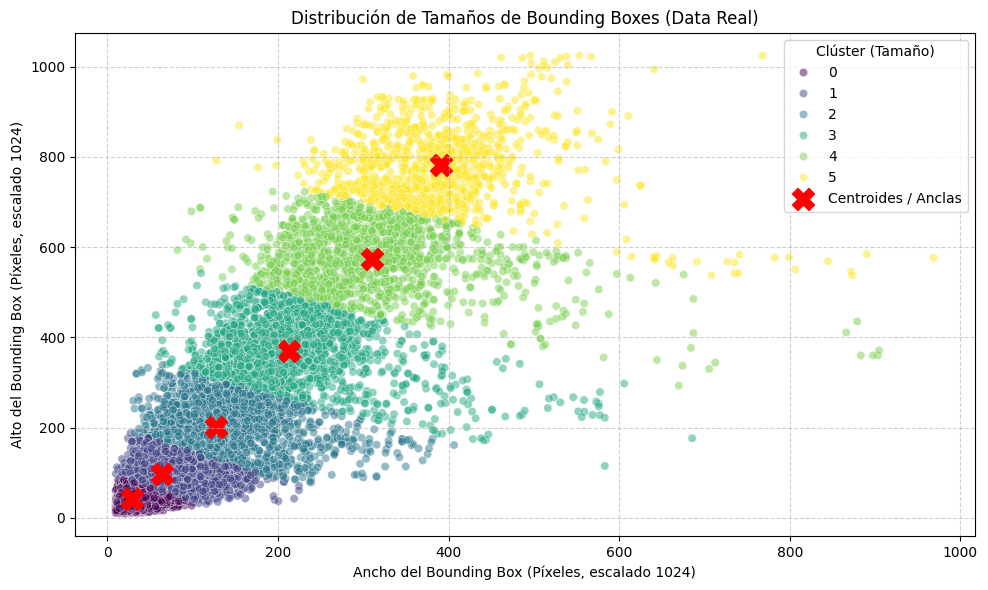

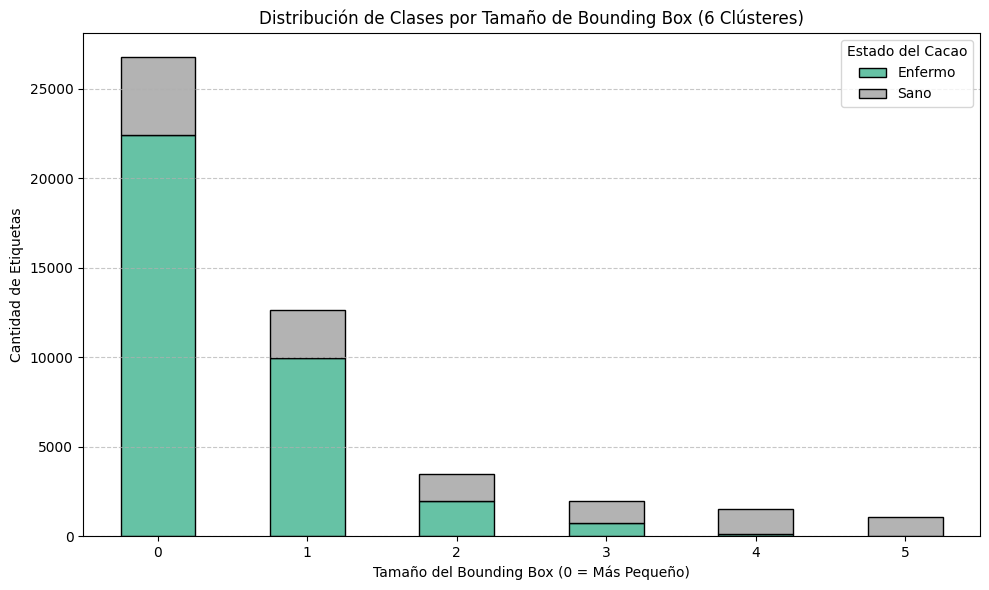


--- Desbalance Global ---
Enfermo: 35165 etiquetas (74.00%)
Sano: 12358 etiquetas (26.00%)


In [ ]:
# ─── Configuración ───────────────────────────────────────────────────────────
target_size   = 1024
min_pixel_size = 10

# Mapeo de clases (ajusta según tu data.yaml)
mapeo_clases = {0: 'Sano', 1: 'Enfermo'}

print("Extrayendo clases y calculando clústeres...")

# ─── Función de extracción unificada ─────────────────────────────────────────
def extraer_datos_completos(txt_path):
    bboxes = []
    stem = Path(txt_path).stem

    if stem not in image_files:
        return bboxes

    img_path = image_files[stem]

    try:
        with Image.open(img_path) as img:
            img_w, img_h = img.size
    except Exception:
        return bboxes

    scale_factor = target_size / max(img_w, img_h)

    try:
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    clase_id = int(parts[0])
                    norm_w   = float(parts[3])
                    norm_h   = float(parts[4])

                    abs_w = norm_w * img_w
                    abs_h = norm_h * img_h

                    scaled_w = abs_w * scale_factor
                    scaled_h = abs_h * scale_factor

                    if scaled_w >= min_pixel_size and scaled_h >= min_pixel_size:
                        bboxes.append({
                            'clase_id':        clase_id,
                            'scaled_bbox_w':   scaled_w,
                            'scaled_bbox_h':   scaled_h,
                            'area_1024':       scaled_w * scaled_h,
                            # Para el scatterplot del Bloque 1
                            'bbox_w':          scaled_w,
                            'bbox_h':          scaled_h,
                            'res_imagen_w':    img_w,
                            'res_imagen_h':    img_h,
                        })
    except Exception:
        pass

    return bboxes

# ─── Procesamiento paralelo (una sola pasada) ─────────────────────────────────
bbox_data_completo = []
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
    resultados = list(tqdm(
        executor.map(extraer_datos_completos, txt_files),
        total=len(txt_files)
    ))

for res in resultados:
    bbox_data_completo.extend(res)

print(f"\n¡Se extrajeron {len(bbox_data_completo)} bounding boxes válidos en total!")

if len(bbox_data_completo) == 0:
    print("ERROR: No se procesó ningún Bounding Box.")
else:
    df_final = pd.DataFrame(bbox_data_completo)
    df_final['nombre_clase'] = df_final['clase_id'].map(
        lambda x: mapeo_clases.get(x, f'Clase_{x}')
    )

    # ─── K-Means con n_grupos (variable ya definida) ──────────────────────────
    n_grupos_real = min(n_grupos, len(df_final))
    X = df_final[['scaled_bbox_w', 'scaled_bbox_h']].values

    kmeans = KMeans(n_clusters=n_grupos_real, random_state=42, n_init=10)
    df_final['cluster_raw'] = kmeans.fit_predict(X)

    # Reordenar clústeres por área promedio (0 = más pequeño)
    orden_tamanos = (
        df_final.groupby('cluster_raw')['area_1024']
        .mean()
        .sort_values()
        .index
    )
    mapeo_tamanos = {old_id: new_id for new_id, old_id in enumerate(orden_tamanos)}
    df_final['Tamano_CIDIS'] = df_final['cluster_raw'].map(mapeo_tamanos)

    # ─── Estadísticas por clúster (Bloque 1) ─────────────────────────────────
    cluster_stats = df_final.groupby('Tamano_CIDIS').agg(
        cantidad_bboxes  = ('Tamano_CIDIS', 'count'),
        bbox_ancho_prom  = ('scaled_bbox_w', 'mean'),
        bbox_alto_prom   = ('scaled_bbox_h', 'mean'),
        res_img_ancho_prom = ('res_imagen_w', 'mean'),
        res_img_alto_prom  = ('res_imagen_h', 'mean'),
    ).reset_index()

    print(f"\n--- Agrupación en {n_grupos_real} clústeres ---")
    display(cluster_stats.round(2))

    # ─── Tabla de contingencia Tamaño × Clase (Bloque 2) ─────────────────────
    tabla_cruzada = pd.crosstab(
        df_final['Tamano_CIDIS'], df_final['nombre_clase'],
        margins=True, margins_name="Total"
    )
    display(tabla_cruzada)

    # ─── Scatterplot de tamaños con centroides ────────────────────────────────
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_final, x='scaled_bbox_w', y='scaled_bbox_h',
        hue='Tamano_CIDIS', palette='viridis', alpha=0.5
    )
    centroides = kmeans.cluster_centers_
    plt.scatter(centroides[:, 0], centroides[:, 1],
                s=250, c='red', marker='X', label='Centroides / Anclas')
    plt.title('Distribución de Tamaños de Bounding Boxes (Data Real)')
    plt.xlabel('Ancho del Bounding Box (Píxeles, escalado 1024)')
    plt.ylabel('Alto del Bounding Box (Píxeles, escalado 1024)')
    plt.legend(title='Clúster (Tamaño)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ─── Barras apiladas por clase ────────────────────────────────────────────
    conteo_clases = (
        df_final.groupby(['Tamano_CIDIS', 'nombre_clase'])
        .size()
        .unstack(fill_value=0)
    )
    conteo_clases.plot(kind='bar', stacked=True, colormap='Set2',
                       figsize=(10, 6), edgecolor='black')
    plt.title(f'Distribución de Clases por Tamaño de Bounding Box ({n_grupos_real} Clústeres)')
    plt.xlabel('Tamaño del Bounding Box (0 = Más Pequeño)')
    plt.ylabel('Cantidad de Etiquetas')
    plt.legend(title='Estado del Cacao')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ─── Desbalance global ────────────────────────────────────────────────────
    total_etiquetas = len(df_final)
    print("\n--- Desbalance Global ---")
    for clase in df_final['nombre_clase'].unique():
        cantidad   = (df_final['nombre_clase'] == clase).sum()
        porcentaje = cantidad / total_etiquetas * 100
        print(f"{clase}: {cantidad} etiquetas ({porcentaje:.2f}%)")

Analizando la resolución de 9799 imágenes en paralelo...


  0%|          | 0/9799 [00:00<?, ?it/s]

Se encontraron 22 resoluciones únicas en 9799 imágenes.


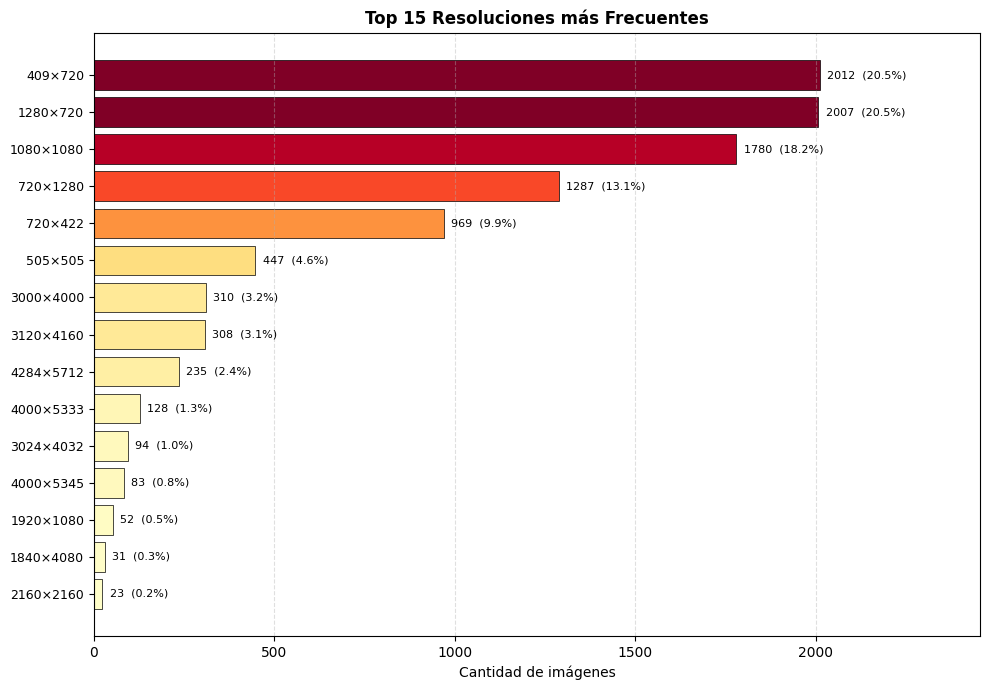

In [ ]:
# Asumimos que el diccionario 'image_files' del paso anterior sigue en la memoria de Colab.
rutas_imagenes = list(image_files.values())

print(f"Analizando la resolución de {len(rutas_imagenes)} imágenes en paralelo...")

# 1. Función para extraer ancho y alto sin cargar los píxeles
def obtener_resolucion(img_path):
    try:
        with Image.open(img_path) as img:
            return {'ancho': img.size[0], 'alto': img.size[1]}
    except Exception:
        return None

# 2. Procesamiento multihilo
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
    resultados = list(tqdm(executor.map(obtener_resolucion, rutas_imagenes), total=len(rutas_imagenes)))

resoluciones = [r for r in resultados if r is not None]
df_res = pd.DataFrame(resoluciones)

# 3. Agrupar por tamaños exactos
conteo_res = df_res.groupby(['ancho', 'alto']).size().reset_index(name='cantidad_imagenes')
conteo_res['porcentaje (%)'] = (conteo_res['cantidad_imagenes'] / len(df_res)) * 100
conteo_res = conteo_res.sort_values('cantidad_imagenes', ascending=False).reset_index(drop=True)
conteo_res['resolucion'] = conteo_res['ancho'].astype(str) + '×' + conteo_res['alto'].astype(str)

n_resoluciones_unicas = len(conteo_res)
print(f"Se encontraron {n_resoluciones_unicas} resoluciones únicas en {len(df_res)} imágenes.")

# 4. Barras horizontales del Top 15
fig, ax = plt.subplots(figsize=(10, 7))

top15 = conteo_res.head(15).iloc[::-1]  # invertir para que el mayor quede arriba
colores = plt.cm.YlOrRd(top15['cantidad_imagenes'] / top15['cantidad_imagenes'].max())

bars = ax.barh(top15['resolucion'], top15['cantidad_imagenes'],
               color=colores, edgecolor='black', linewidth=0.5)

# Etiquetas de valor y porcentaje al final de cada barra
for bar, (_, row) in zip(bars, top15.iterrows()):
    ax.text(
        bar.get_width() + conteo_res['cantidad_imagenes'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['cantidad_imagenes'])}  ({row['porcentaje (%)']:.1f}%)",
        va='center', fontsize=8
    )

ax.set_title('Top 15 Resoluciones más Frecuentes', fontsize=12, fontweight='bold')
ax.set_xlabel('Cantidad de imágenes')
ax.set_xlim(right=conteo_res['cantidad_imagenes'].max() * 1.22)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

### Visualización de reescalado y filtrado por tamaño de bounding box


--- Simulando escalado a 1024x1024 con umbral de 10px ---
Bboxes originales: 48776
Bboxes conservados: 47523
Bboxes eliminados por ser menores a 10px: 1253 (2.57%)

--- Agrupación en 6 clústeres (Escalado a 1024) ---


,cluster_scaled,cantidad_bboxes,bbox_ancho_1024_prom,bbox_alto_1024_prom
0,0,12662,64.11,97.06
1,1,1541,309.66,574.64
2,2,3491,127.89,202.05
3,3,1976,213.48,368.52
4,4,26793,28.87,42.46
5,5,1060,391.58,780.87


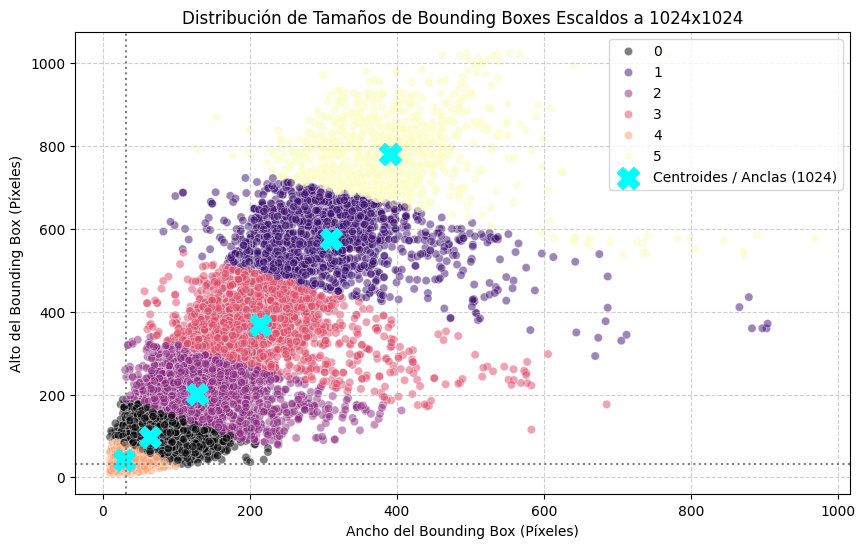

In [ ]:
# 6. Simulación de Escalado a 1024 y Filtrado
target_size = 1024
min_pixel_size = 10

print(f"\n--- Simulando escalado a {target_size}x{target_size} con umbral de {min_pixel_size}px ---")

# Calcular el factor de escala manteniendo la relación de aspecto (letterbox)
# El lado más largo dictará cuánto se debe reducir la imagen para caber en 1024
df_bboxes['scale_factor'] = target_size / df_bboxes[['res_imagen_w', 'res_imagen_h']].max(axis=1)

# Aplicar el escalado a las cajas
df_bboxes['scaled_bbox_w'] = df_bboxes['bbox_w'] * df_bboxes['scale_factor']
df_bboxes['scaled_bbox_h'] = df_bboxes['bbox_h'] * df_bboxes['scale_factor']

# Filtrar cajas que sean demasiado pequeñas para la red neuronal
df_filtrado = df_bboxes[(df_bboxes['scaled_bbox_w'] >= min_pixel_size) &
                        (df_bboxes['scaled_bbox_h'] >= min_pixel_size)].copy()

cajas_eliminadas = len(df_bboxes) - len(df_filtrado)
print(f"Bboxes originales: {len(df_bboxes)}")
print(f"Bboxes conservados: {len(df_filtrado)}")
print(f"Bboxes eliminados por ser menores a {min_pixel_size}px: {cajas_eliminadas} ({cajas_eliminadas/len(df_bboxes)*100:.2f}%)")

if len(df_filtrado) > 0:
    # Aplicar K-Means a los datos escalados
    X_scaled = df_filtrado[['scaled_bbox_w', 'scaled_bbox_h']].values
    n_grupos_scaled = min(n_grupos, len(X_scaled))

    kmeans_scaled = KMeans(n_clusters=n_grupos_scaled, random_state=42, n_init=10)
    df_filtrado['cluster_scaled'] = kmeans_scaled.fit_predict(X_scaled)

    # Mostrar estadísticas del dataset simulado a 1024
    cluster_stats_scaled = df_filtrado.groupby('cluster_scaled').agg(
        cantidad_bboxes=('cluster_scaled', 'count'),
        bbox_ancho_1024_prom=('scaled_bbox_w', 'mean'),
        bbox_alto_1024_prom=('scaled_bbox_h', 'mean')
    ).reset_index()

    print(f"\n--- Agrupación en {n_grupos_scaled} clústeres (Escalado a 1024) ---")
    display(cluster_stats_scaled.round(2))

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_filtrado,
        x='scaled_bbox_w',
        y='scaled_bbox_h',
        hue='cluster_scaled',
        palette='magma',
        alpha=0.5
    )

    centroides_scaled = kmeans_scaled.cluster_centers_
    plt.scatter(centroides_scaled[:, 0], centroides_scaled[:, 1], s=250, c='cyan', marker='X', label='Centroides / Anclas (1024)')

    plt.title(f'Distribución de Tamaños de Bounding Boxes Escaldos a {target_size}x{target_size}')
    plt.xlabel('Ancho del Bounding Box (Píxeles)')
    plt.ylabel('Alto del Bounding Box (Píxeles)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Líneas de referencia visual para objetos "pequeños" en la literatura (32x32)
    plt.axvline(x=32, color='gray', linestyle=':', label='Límite Objeto Pequeño (COCO)')
    plt.axhline(y=32, color='gray', linestyle=':')

    plt.show()
else:
    print("El dataset quedó vacío tras el filtrado. Revisa tu umbral.")

### Eliminación de Boundin Boxes pequeñas

In [ ]:
import os
from pathlib import Path
from PIL import Image
import concurrent.futures
from tqdm.notebook import tqdm

# 1. Configuración del filtro
target_size = 1024
min_pixel_size = 10
dataset_path = Path(dataset.location)

print(f"Iniciando limpieza física de etiquetas en: {dataset_path}")

# 2. Recopilar rutas (usamos la misma lógica global que ya demostró funcionar)
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPG', '.PNG'}
image_files = {}
txt_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = Path(file).suffix.lower()
        if ext in image_extensions:
            image_files[Path(file).stem] = os.path.join(root, file)
        elif ext == '.txt':
            if file.lower() not in ['classes.txt', 'readme.txt', 'data.txt']:
                txt_files.append(os.path.join(root, file))

# 3. Función para filtrar un archivo .txt
def limpiar_etiqueta(txt_path):
    stem = Path(txt_path).stem
    bboxes_eliminados = 0
    bboxes_conservados = 0

    if stem not in image_files:
        return 0, 0 # No hay imagen asociada, no hacemos nada

    img_path = image_files[stem]

    # Obtener dimensiones originales de la imagen
    try:
        with Image.open(img_path) as img:
            img_w, img_h = img.size
    except Exception:
        return 0, 0

    # Calcular factor de escala letterbox (YOLO ajusta por el lado más largo)
    scale_factor = target_size / max(img_w, img_h)

    lineas_validas = []

    # Leer el archivo y filtrar
    try:
        with open(txt_path, 'r') as f:
            lineas = f.readlines()

        for line in lineas:
            parts = line.strip().split()
            if len(parts) >= 5:
                norm_w = float(parts[3])
                norm_h = float(parts[4])

                # Tamaño absoluto original
                abs_w = norm_w * img_w
                abs_h = norm_h * img_h

                # Tamaño simulado a 1024
                scaled_w = abs_w * scale_factor
                scaled_h = abs_h * scale_factor

                # Criterio de supervivencia
                if scaled_w >= min_pixel_size and scaled_h >= min_pixel_size:
                    lineas_validas.append(line)
                    bboxes_conservados += 1
                else:
                    bboxes_eliminados += 1

        # Sobrescribir el archivo .txt solo con las líneas válidas
        # Si lineas_validas está vacío, el archivo quedará en blanco (Background Image)
        with open(txt_path, 'w') as f:
            f.writelines(lineas_validas)

    except Exception as e:
        pass

    return bboxes_eliminados, bboxes_conservados

# 4. Procesamiento Paralelo Multihilo para hacerlo rápido
total_eliminados = 0
total_conservados = 0

print("\nFiltrando archivos .txt...")
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
    resultados = list(tqdm(executor.map(limpiar_etiqueta, txt_files), total=len(txt_files)))

for eliminados, conservados in resultados:
    total_eliminados += eliminados
    total_conservados += conservados

print("\n--- Resumen de Limpieza ---")
print(f"Bboxes conservados: {total_conservados}")
print(f"Bboxes eliminados permanentemente: {total_eliminados}")
print("El dataset está listo para entrenar.")

### Bloque 3: Entrenamiento de YOLO26s

In [ ]:
from ultralytics import YOLO

# Cargar la arquitectura YOLO26 small
model_yolo = YOLO('yolo26s.pt')

# Iniciar entrenamiento
resultados_yolo = model_yolo.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,             # Ajusta según el comportamiento de la pérdida
    imgsz=1024,            # Alta resolución para mantener detalle en imágenes 3024x4032
    batch=8,               # Batch conservador para evitar que la GPU (T4 en Colab) colapse
    project=f"{"/content/"}/Modelos_Cacao",
    name="YOLO26s_Entrenado"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Cacao_Project/qwwp_⭐-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

Mean of empty slice.
invalid value encountered in divide



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      7.15G          0  2.112e-06          0          3       1024: 100% ━━━━━━━━━━━━ 864/864 1.8it/s 8:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 117/117 1.9it/s 1:02
                   all       1858          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


Mean of empty slice.
invalid value encountered in divide



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      7.15G          0  2.884e-06          0          8       1024: 22% ━━╸───────── 186/864 3.6it/s 1:47<3:11


KeyboardInterrupt: 

### Smart Filtter

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 1 · Configuración de cuotas — AJUSTA ESTOS VALORES       ║
# ╚══════════════════════════════════════════════════════════════════╝

# Número de bins (debe coincidir con n_grupos del K-Means)
N_BINS = 6

# Cuota objetivo de IMÁGENES por (bin, clase).
# Con 6 bins × 2 clases × 333 imágenes ≈ 4000 imágenes totales
# → si cada imagen tiene ~5 bboxes promedio ≈ 20 000 etiquetas.
# Ajusta TARGET_PER_BUCKET según tus conteos reales.
TARGET_PER_BUCKET = 333

# Estrategia cuando una imagen pertenece a múltiples bins:
#   'dominant'  → asignarla al bin con más bboxes (recomendado)
#   'multi'     → contarla en TODOS los bins que representa
ASSIGNMENT_STRATEGY = 'dominant'

# Mapeo de clases (igual que en las celdas anteriores)
MAPEO_CLASES = {0: 'Sano', 1: 'Enfermo'}

# Semilla aleatoria para reproducibilidad
RANDOM_SEED = 42

print('Configuración cargada:')
print(f'  · N_BINS             = {N_BINS}')
print(f'  · TARGET_PER_BUCKET  = {TARGET_PER_BUCKET} imágenes por (bin, clase)')
print(f'  · Total objetivo     ≤ {N_BINS * 2 * TARGET_PER_BUCKET} imágenes')
print(f'  · Estrategia         = {ASSIGNMENT_STRATEGY}')


Configuración cargada:
  · N_BINS             = 6
  · TARGET_PER_BUCKET  = 333 imágenes por (bin, clase)
  · Total objetivo     ≤ 3996 imágenes
  · Estrategia         = dominant


In [ ]:
# ── Regenerar df_final con image_stem incluido ────────────────────
from pathlib import Path
from PIL import Image
import concurrent.futures
from tqdm.notebook import tqdm

target_size    = 1024
min_pixel_size = 10
mapeo_clases   = {0: 'Sano', 1: 'Enfermo'}

# Reutiliza los SIZE_BINS que ya definiste para Tamano_CIDIS
# Ajusta estos límites si los tienes definidos de otra forma
SIZE_BINS = {
    1: (0,    32),
    2: (32,   64),
    3: (64,   128),
    4: (128,  256),
    5: (256,  512),
    6: (512,  9999),
}

def asignar_tamano_cidis(area):
    lado = area ** 0.5  # lado equivalente del bbox escalado
    for bin_id, (lo, hi) in SIZE_BINS.items():
        if lo <= lado < hi:
            return bin_id
    return 6

def extraer_con_stem(txt_path):
    rows = []
    stem = Path(txt_path).stem
    if stem not in image_files:
        return rows
    img_path = image_files[stem]
    try:
        with Image.open(img_path) as img:
            img_w, img_h = img.size
    except Exception:
        return rows
    scale_factor = target_size / max(img_w, img_h)
    try:
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    clase_id = int(parts[0])
                    abs_w = float(parts[3]) * img_w
                    abs_h = float(parts[4]) * img_h
                    sw = abs_w * scale_factor
                    sh = abs_h * scale_factor
                    if sw >= min_pixel_size and sh >= min_pixel_size:
                        area = sw * sh
                        rows.append({
                            'image_stem':    stem,
                            'clase_id':      clase_id,
                            'nombre_clase':  mapeo_clases.get(clase_id, f'Clase_{clase_id}'),
                            'scaled_bbox_w': sw,
                            'scaled_bbox_h': sh,
                            'area_1024':     area,
                            'Tamano_CIDIS':  asignar_tamano_cidis(area),
                        })
    except Exception:
        pass
    return rows

print("Regenerando df_final con image_stem...")
all_rows = []
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as ex:
    for res in tqdm(ex.map(extraer_con_stem, txt_files), total=len(txt_files)):
        all_rows.extend(res)

df_final = pd.DataFrame(all_rows)

# Mapear cluster_id desde Tamano_CIDIS (son equivalentes)
df_final['cluster_id'] = df_final['Tamano_CIDIS']

print(f"\ndf_final regenerado: {len(df_final)} bboxes · {df_final['image_stem'].nunique()} imágenes únicas")
print(f"Columnas: {df_final.columns.tolist()}")
display(df_final.head(3))

Regenerando df_final con image_stem...


  0%|          | 0/9801 [00:00<?, ?it/s]


df_final regenerado: 47523 bboxes · 9201 imágenes únicas
Columnas: ['image_stem', 'clase_id', 'nombre_clase', 'scaled_bbox_w', 'scaled_bbox_h', 'area_1024', 'Tamano_CIDIS', 'cluster_id']


,image_stem,clase_id,nombre_clase,scaled_bbox_w,scaled_bbox_h,area_1024,Tamano_CIDIS,cluster_id
0,train_0003278_jpg.rf.211e7e4daa0c45c059506d3e8...,1,Enfermo,28.000,32.000,896.000000,1,1
1,train_0003278_jpg.rf.211e7e4daa0c45c059506d3e8...,1,Enfermo,32.264,58.376,1883.443264,2,2
2,train_0003278_jpg.rf.211e7e4daa0c45c059506d3e8...,1,Enfermo,21.040,47.016,989.216640,1,1


=== Cobertura del dataset real por (Bin, Clase) ===


' cluster_id nombre_clase  n_imagenes  total_bboxes\n          1         Sano        1075          2125\n          1      Enfermo        3069          9841\n          2         Sano        1425          2839\n          2      Enfermo        4341         15231\n          3         Sano        1435          2357\n          3      Enfermo        3480          7709\n          4         Sano        1239          1711\n          4      Enfermo        1226          1882\n          5         Sano        2263          2525\n          5      Enfermo         411           492\n          6         Sano         786           801\n          6      Enfermo          10            10'


=== Alertas de escasez (imágenes < TARGET_PER_BUCKET) ===
  ⚠ Bin 6 · Enfermo: 10 imgs disponibles (déficit de 323 imgs → se usarán todas las disponibles)


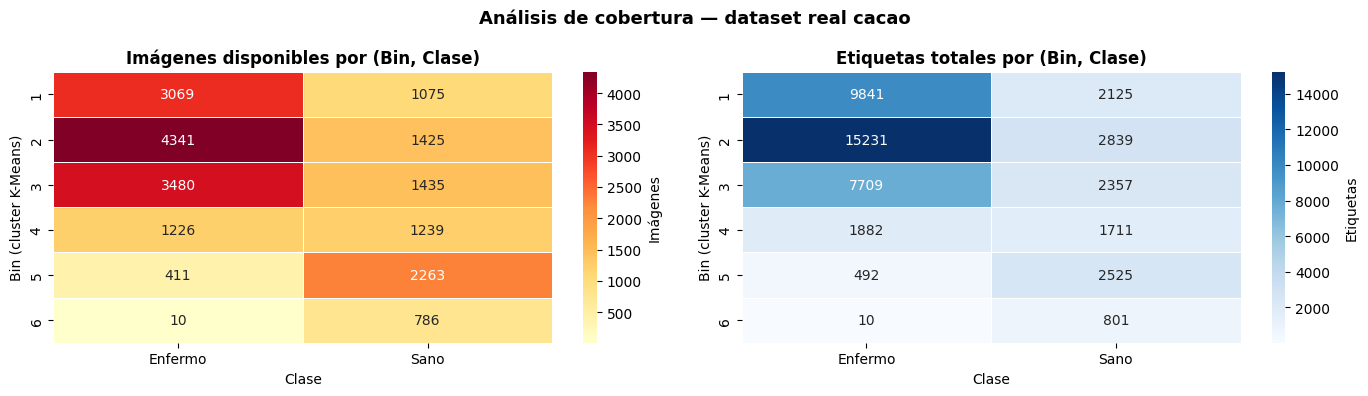

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 2 · Etapa 1: Análisis de cobertura del dataset real      ║
# ╚══════════════════════════════════════════════════════════════════╝
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Asegurar que df_final tiene la columna image_stem ──────────────
if 'txt_path' in df_final.columns and 'image_stem' not in df_final.columns:
    df_final['image_stem'] = df_final['txt_path'].apply(lambda p: Path(p).stem)

# ── Tabla de cobertura: por imagen → cuántos bboxes tiene en cada (bin, clase)
coverage = (
    df_final
    .groupby(['image_stem', 'cluster_id', 'clase_id'])
    .size()
    .reset_index(name='n_bboxes')
)

# ── Resumen global: cuántas ETIQUETAS existen por (bin, clase) ─────
resumen_etiquetas = (
    coverage
    .groupby(['cluster_id', 'clase_id'])['n_bboxes']
    .agg(total_bboxes='sum', n_imagenes='count')
    .reset_index()
)
resumen_etiquetas['nombre_clase'] = resumen_etiquetas['clase_id'].map(MAPEO_CLASES)
resumen_etiquetas = resumen_etiquetas.sort_values(['cluster_id', 'clase_id'])

print('=== Cobertura del dataset real por (Bin, Clase) ===')
display(resumen_etiquetas[['cluster_id','nombre_clase','n_imagenes','total_bboxes']].to_string(index=False))

# ── Alerta de escasez ──────────────────────────────────────────────
print('\n=== Alertas de escasez (imágenes < TARGET_PER_BUCKET) ===')
alertas = resumen_etiquetas[resumen_etiquetas['n_imagenes'] < TARGET_PER_BUCKET]
if alertas.empty:
    print('  ✓ Todos los bins tienen cobertura suficiente.')
else:
    for _, row in alertas.iterrows():
        deficit = TARGET_PER_BUCKET - row['n_imagenes']
        print(f'  ⚠ Bin {int(row["cluster_id"])} · {row["nombre_clase"]}: '
              f'{int(row["n_imagenes"])} imgs disponibles '
              f'(déficit de {deficit} imgs → se usarán todas las disponibles)')

# ── Heatmap de disponibilidad ──────────────────────────────────────
pivot_disp = resumen_etiquetas.pivot(index='cluster_id', columns='nombre_clase', values='n_imagenes')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap imágenes
sns.heatmap(pivot_disp, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Imágenes'})
axes[0].set_title('Imágenes disponibles por (Bin, Clase)', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Bin (cluster K-Means)')

# Heatmap etiquetas
pivot_bboxes = resumen_etiquetas.pivot(index='cluster_id', columns='nombre_clase', values='total_bboxes')
sns.heatmap(pivot_bboxes, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Etiquetas'})
axes[1].set_title('Etiquetas totales por (Bin, Clase)', fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Bin (cluster K-Means)')

# Línea de cuota objetivo
axes[0].axhline(y=0, color='lime', linewidth=0, label=f'Target: {TARGET_PER_BUCKET}')
fig.suptitle('Análisis de cobertura — dataset real cacao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 3 · Etapa 2: Bin primario por imagen                     ║
# ╚══════════════════════════════════════════════════════════════════╝

if ASSIGNMENT_STRATEGY == 'dominant':
    # Para cada imagen, el bin dominante es el que tiene más bboxes
    dominant_bin = (
        coverage
        .sort_values('n_bboxes', ascending=False)
        .groupby('image_stem', as_index=False)
        .first()[['image_stem', 'cluster_id']]
        .rename(columns={'cluster_id': 'bin_dominante'})
    )

    # Tabla de trabajo: una fila por (imagen, clase) con su bin dominante
    # y cuántos bboxes tiene de cada clase en ese bin
    df_work = (
        coverage
        .merge(dominant_bin, on='image_stem')
        .groupby(['image_stem', 'bin_dominante', 'clase_id'])
        .agg(total_bboxes_clase=('n_bboxes', 'sum'))
        .reset_index()
    )

elif ASSIGNMENT_STRATEGY == 'multi':
    # Cada imagen puede aparecer en TODOS sus bins
    df_work = coverage.rename(columns={'cluster_id': 'bin_dominante'}).copy()
    df_work['total_bboxes_clase'] = df_work['n_bboxes']

# Enriquecer con nombre de clase
df_work['nombre_clase'] = df_work['clase_id'].map(MAPEO_CLASES)

# Vista rápida
print(f'Estrategia: {ASSIGNMENT_STRATEGY}')
print(f'Imágenes únicas en el pool de trabajo: {df_work["image_stem"].nunique()}')
print(f'Filas en df_work (imagen × bin × clase): {len(df_work)}')
print()
print('Primeras filas de df_work:')
display(df_work.head(10))


Estrategia: dominant
Imágenes únicas en el pool de trabajo: 9201
Filas en df_work (imagen × bin × clase): 11704

Primeras filas de df_work:


,image_stem,bin_dominante,clase_id,total_bboxes_clase,nombre_clase
0,0_jpg.rf.9d5f8e73425e2a14f7927ffe46d547ec,5,0,1,Sano
1,100_jpg.rf.62717ce7b44af92f2f9058fc2c15c29d,5,0,1,Sano
2,101_jpg.rf.7cb5447aab24219fee338c93d88a6021,5,0,1,Sano
3,103_jpg.rf.5f41d070f8bd1c30d23b7616003d0005,6,0,1,Sano
4,104_jpg.rf.82b0c796d8e408ebd5252efdefb5f747,6,0,1,Sano
5,105_jpg.rf.a985c859dc2da97d37800b3367a50eaf,5,0,2,Sano
6,107_jpg.rf.be73ae6f2e0d8ae9f8017cf7c2d63b91,5,0,2,Sano
7,108_jpg.rf.052d2af9302296830945c6a65053d0c1,5,0,1,Sano
8,109_jpg.rf.820f2c0785206ce63b45f64e16220829,5,0,1,Sano
9,10_jpg.rf.9e660fff20b8a99d7543ab4165fb6446,6,0,2,Sano


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 4 · Etapa 3: Muestreo estratificado + deduplicación      ║
# ╚══════════════════════════════════════════════════════════════════╝
import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

selected_images = set()
selection_log   = []   # log detallado para auditoría

# Iterar por (bin, clase) ordenando de menor a mayor disponibilidad
# → los buckets más escasos tienen prioridad de selección
clases_ids = sorted(df_work['clase_id'].unique())

grupos = (
    df_work
    .groupby(['bin_dominante', 'clase_id'])['image_stem']
    .apply(list)
    .reset_index()
)
grupos['n_disponibles'] = grupos['image_stem'].apply(len)
grupos = grupos.sort_values('n_disponibles')  # escasos primero

for _, row in grupos.iterrows():
    bin_id    = row['bin_dominante']
    clase_id  = row['clase_id']
    pool      = row['image_stem']
    n_disp    = len(pool)

    # Excluir imágenes ya asignadas en iteraciones anteriores
    pool_libre = [img for img in pool if img not in selected_images]

    # Calcular cuántas necesitamos aún (respetando el target)
    ya_seleccionadas_bucket = sum(
        1 for log in selection_log
        if log['bin'] == bin_id and log['clase_id'] == clase_id
    )
    necesitamos = max(0, TARGET_PER_BUCKET - ya_seleccionadas_bucket)
    n_tomar     = min(necesitamos, len(pool_libre))

    elegidas = random.sample(pool_libre, n_tomar) if n_tomar > 0 else []

    for img in elegidas:
        selected_images.add(img)
        selection_log.append({
            'image_stem': img,
            'bin': bin_id,
            'clase_id': clase_id,
            'nombre_clase': MAPEO_CLASES.get(clase_id, f'Clase_{clase_id}')
        })

df_selected = pd.DataFrame(selection_log)

print(f'=== Resultado del muestreo ===')
print(f'Imágenes únicas seleccionadas: {len(selected_images)}')
print()

# Estadísticas finales por (bin, clase)
resumen_sel = (
    df_selected
    .groupby(['bin', 'nombre_clase'])
    .size()
    .reset_index(name='n_imagenes_seleccionadas')
    .sort_values(['bin', 'nombre_clase'])
)
print('Imágenes seleccionadas por (Bin, Clase):')
display(resumen_sel)


=== Resultado del muestreo ===
Imágenes únicas seleccionadas: 3692

Imágenes seleccionadas por (Bin, Clase):


,bin,nombre_clase,n_imagenes_seleccionadas
0,1,Enfermo,333
1,1,Sano,333
2,2,Enfermo,333
3,2,Sano,333
4,3,Enfermo,333
5,3,Sano,333
6,4,Enfermo,333
7,4,Sano,333
8,5,Enfermo,333
9,5,Sano,333


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 5 · Etapa 4: Conteo real de etiquetas en el subset       ║
# ╚══════════════════════════════════════════════════════════════════╝

# Bboxes efectivos que quedan en el subset seleccionado
df_subset_bboxes = df_final[df_final['image_stem'].isin(selected_images)].copy()
df_subset_bboxes['nombre_clase'] = df_subset_bboxes['clase_id'].map(MAPEO_CLASES)

total_bboxes_subset = len(df_subset_bboxes)
total_imgs_subset   = df_subset_bboxes['image_stem'].nunique()

print(f'=== Resumen final del subset ===')
print(f'  · Imágenes únicas   : {total_imgs_subset}')
print(f'  · Etiquetas totales : {total_bboxes_subset}')
print(f'  · Bboxes por imagen : {total_bboxes_subset / total_imgs_subset:.1f} promedio')
print()

# Distribución por clase
dist_clase = df_subset_bboxes['nombre_clase'].value_counts()
print('Distribución por clase:')
for cls, cnt in dist_clase.items():
    print(f'  {cls}: {cnt} ({cnt/total_bboxes_subset*100:.1f}%)')
print()

# Distribución por bin
dist_bin = df_subset_bboxes['cluster_id'].value_counts().sort_index()
print('Distribución por bin (cluster):')
for bin_id, cnt in dist_bin.items():
    print(f'  Bin {bin_id}: {cnt} etiquetas ({cnt/total_bboxes_subset*100:.1f}%)')


=== Resumen final del subset ===
  · Imágenes únicas   : 3692
  · Etiquetas totales : 19860
  · Bboxes por imagen : 5.4 promedio

Distribución por clase:
  Enfermo: 13540 (68.2%)
  Sano: 6320 (31.8%)

Distribución por bin (cluster):
  Bin 1: 5362 etiquetas (27.0%)
  Bin 2: 6089 etiquetas (30.7%)
  Bin 3: 4503 etiquetas (22.7%)
  Bin 4: 2310 etiquetas (11.6%)
  Bin 5: 1213 etiquetas (6.1%)
  Bin 6: 383 etiquetas (1.9%)


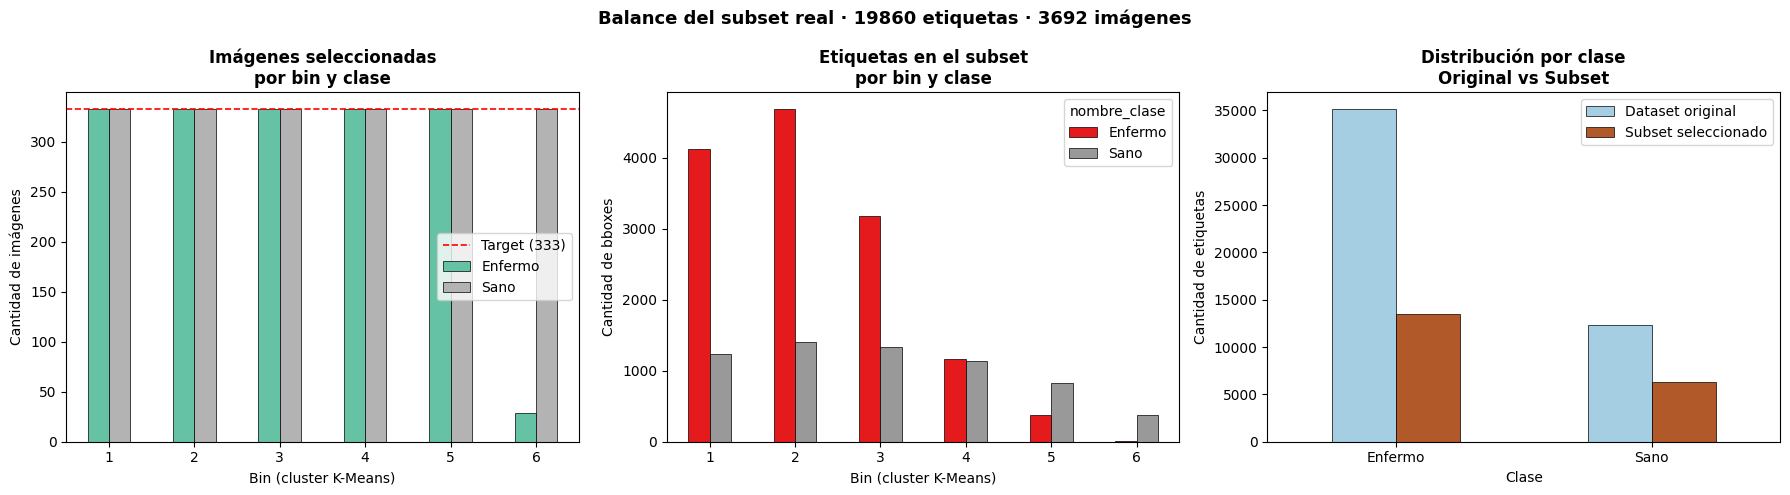

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 6 · Etapa 5: Visualización del balance del subset        ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfica 1: Imágenes seleccionadas por (Bin, Clase) ----
pivot_sel = resumen_sel.pivot(index='bin', columns='nombre_clase', values='n_imagenes_seleccionadas').fillna(0)
pivot_sel.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', linewidth=0.5)
axes[0].axhline(y=TARGET_PER_BUCKET, color='red', linestyle='--', linewidth=1.2, label=f'Target ({TARGET_PER_BUCKET})')
axes[0].set_title('Imágenes seleccionadas\npor bin y clase', fontweight='bold')
axes[0].set_xlabel('Bin (cluster K-Means)')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# --- Gráfica 2: Etiquetas en el subset por (Bin, Clase) ----
pivot_bboxes_sel = (
    df_subset_bboxes
    .groupby(['cluster_id', 'nombre_clase'])
    .size()
    .reset_index(name='n_bboxes')
    .pivot(index='cluster_id', columns='nombre_clase', values='n_bboxes')
    .fillna(0)
)
pivot_bboxes_sel.plot(kind='bar', ax=axes[1], colormap='Set1', edgecolor='black', linewidth=0.5)
axes[1].set_title('Etiquetas en el subset\npor bin y clase', fontweight='bold')
axes[1].set_xlabel('Bin (cluster K-Means)')
axes[1].set_ylabel('Cantidad de bboxes')
axes[1].tick_params(axis='x', rotation=0)

# --- Gráfica 3: Comparación original vs subset ----
comp_data = pd.DataFrame({
    'Dataset original': df_final['nombre_clase'].value_counts(),
    'Subset seleccionado': df_subset_bboxes['nombre_clase'].value_counts()
})
comp_data.plot(kind='bar', ax=axes[2], colormap='Paired', edgecolor='black', linewidth=0.5)
axes[2].set_title('Distribución por clase\nOriginal vs Subset', fontweight='bold')
axes[2].set_xlabel('Clase')
axes[2].set_ylabel('Cantidad de etiquetas')
axes[2].tick_params(axis='x', rotation=0)

fig.suptitle(f'Balance del subset real · {total_bboxes_subset} etiquetas · {total_imgs_subset} imágenes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 7 · Etapa 6: Exportación del subset                      ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
import shutil

# ── Rutas de exportación (en Google Drive) ─────────────────────────
export_base = Path('/content/drive/MyDrive/Cacao_Project/subset_real')
for split in ['train', 'valid', 'test']:
    (export_base / split / 'images').mkdir(parents=True, exist_ok=True)
    (export_base / split / 'labels').mkdir(parents=True, exist_ok=True)

# ── Split estratificado train/valid/test (70/15/15) ────────────────
# Estratificamos por (bin_dominante, clase_id) para mantener balance
from sklearn.model_selection import train_test_split

df_split_pool = df_selected.drop_duplicates(subset='image_stem')
# Crear etiqueta combinada para estratificación
df_split_pool['strat_label'] = (
    df_split_pool['bin'].astype(str) + '_' + df_split_pool['clase_id'].astype(str)
)

train_imgs, temp_imgs = train_test_split(
    df_split_pool['image_stem'].tolist(),
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_split_pool['strat_label']
)
df_temp = df_split_pool[df_split_pool['image_stem'].isin(temp_imgs)]
valid_imgs, test_imgs = train_test_split(
    df_temp['image_stem'].tolist(),
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=df_temp['strat_label']
)

split_map = (
    {img: 'train' for img in train_imgs} |
    {img: 'valid' for img in valid_imgs} |
    {img: 'test'  for img in test_imgs}
)

print(f'Split: train={len(train_imgs)} · valid={len(valid_imgs)} · test={len(test_imgs)}')
print()

# ── Copiar imágenes y etiquetas ────────────────────────────────────
copiados = 0
errores  = 0

for stem, split_name in split_map.items():
    if stem not in image_files:
        errores += 1
        continue

    img_src  = image_files[stem]
    img_ext  = Path(img_src).suffix
    img_dst  = export_base / split_name / 'images' / f'{stem}{img_ext}'

    # Buscar el .txt asociado
    # image_files → dict de stem a ruta; asumimos txt en la misma carpeta
    txt_src_candidates = [
        Path(img_src).with_suffix('.txt'),
        Path(str(img_src).replace('/images/', '/labels/')).with_suffix('.txt')
    ]
    txt_src = next((p for p in txt_src_candidates if p.exists()), None)

    try:
        shutil.copy2(img_src, img_dst)
        if txt_src:
            txt_dst = export_base / split_name / 'labels' / f'{stem}.txt'
            shutil.copy2(txt_src, txt_dst)
        copiados += 1
    except Exception as e:
        errores += 1

print(f'Archivos copiados: {copiados}')
print(f'Errores al copiar: {errores}')


Split: train=2584 · valid=554 · test=554

Archivos copiados: 3692
Errores al copiar: 0


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELDA 8 · Etapa 7: Reporte CSV + data.yaml del subset          ║
# ╚══════════════════════════════════════════════════════════════════╝
import yaml

# ── Reporte de selección ───────────────────────────────────────────
df_report = df_selected.copy()
df_report['split'] = df_report['image_stem'].map(split_map)
df_report['n_bboxes_total'] = df_report['image_stem'].map(
    df_subset_bboxes.groupby('image_stem').size()
)
df_report.to_csv(export_base / 'selection_report.csv', index=False)
print('selection_report.csv guardado.')

# ── Resumen de métricas de balance ────────────────────────────────
metricas = (
    df_subset_bboxes
    .groupby(['cluster_id', 'nombre_clase'])
    .agg(
        n_imagenes=('image_stem', 'nunique'),
        n_bboxes=('clase_id', 'count'),
        bbox_area_mean=('area_1024', 'mean'),
        bbox_area_std=('area_1024', 'std')
    )
    .reset_index()
)
metricas.to_csv(export_base / 'balance_metrics.csv', index=False)
print('balance_metrics.csv guardado.')
display(metricas.round(2))

# ── data.yaml para YOLO ────────────────────────────────────────────
data_yaml = {
    'path': str(export_base),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': len(MAPEO_CLASES),
    'names': [MAPEO_CLASES[i] for i in sorted(MAPEO_CLASES.keys())]
}
with open(export_base / 'data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'\ndata.yaml guardado en {export_base / "data.yaml"}')
print()
print('=== Resumen final del módulo Smart Sampler ===')
print(f'  · Imágenes en train : {len(train_imgs)}')
print(f'  · Imágenes en valid : {len(valid_imgs)}')
print(f'  · Imágenes en test  : {len(test_imgs)}')
print(f'  · Etiquetas totales : {total_bboxes_subset}')
print(f'  · Archivos generados: selection_report.csv · balance_metrics.csv · data.yaml')


selection_report.csv guardado.
balance_metrics.csv guardado.


,cluster_id,nombre_clase,n_imagenes,n_bboxes,bbox_area_mean,bbox_area_std
0,1,Enfermo,1193,4126,563.13,240.27
1,1,Sano,608,1236,583.42,231.82
2,2,Enfermo,1526,4686,2185.44,854.52
3,2,Sano,750,1403,2210.62,874.45
4,3,Enfermo,1403,3171,7680.76,3146.40
5,3,Sano,783,1332,8411.39,3311.29
6,4,Enfermo,739,1167,33632.47,13493.33
7,4,Sano,787,1143,35019.81,14157.98
8,5,Enfermo,313,380,109274.67,40914.28
9,5,Sano,719,833,142627.42,56836.67



data.yaml guardado en /content/drive/MyDrive/Cacao_Project/subset_real/data.yaml

=== Resumen final del módulo Smart Sampler ===
  · Imágenes en train : 2584
  · Imágenes en valid : 554
  · Imágenes en test  : 554
  · Etiquetas totales : 19860
  · Archivos generados: selection_report.csv · balance_metrics.csv · data.yaml
